<a href="https://colab.research.google.com/github/Adrian-Ang012/Eskwelab-Aviation-Revenue-Ancillary-Attach-Pricing-Simulation/blob/main/showcase_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CHAPTER 1: Introduction

Airline revenue management has evolved significantly over the past decades, moving beyond traditional seat inventory control toward more sophisticated pricing strategies that incorporate ancillary products such as baggage, seat selection, and in-flight services. These ancillary offerings now represent a substantial share of airline revenue, making the ability to understand and predict passenger purchasing behavior increasingly important.

---

## 1.1 The Challenge of Data Accessibility

A significant barrier exists for researchers and practitioners in this field:
* **Proprietary Restrictions:** High-quality airline transaction data is typically restricted due to commercial sensitivity and privacy regulations.
* **Limited Scope:** Many existing studies rely on small or simplified datasets that fail to capture the complexity of real-world booking behavior.

---

## 1.2 The Behavioral Synthetic Data Engine (BSDE)

To address these limitations, this study introduces the **Behavioral Synthetic Data Engine (BSDE)**. This simulation framework is designed to generate large-scale synthetic datasets that replicate key economic and behavioral dynamics present in airline ancillary purchasing.



### **Core Simulation Principles**
The BSDE embeds structured behavioral mechanisms that resemble real passenger decision-making processes, including:

* **Heterogeneous Sensitivity:** Modeling different price sensitivities across various passenger segments.
* **Dynamic Scarcity:** Reflecting how inventory availability influences purchase urgency.
* **The Elena Ceiling:** A nonlinear demand threshold where purchase probability declines sharply once ancillary prices exceed a specific proportion of the base fare.

---

## 1.3 Objectives and Contributions

Using the generated dataset, this Notebook will demonstrate the application of exploratory data analysis and machine learning to:
1. **Uncover Patterns:** Identify behavioral pricing patterns within the noise of transaction data.
2. **Probability Estimation:** Train predictive models to recover economically meaningful relationships.
3. **Revenue Optimization:** Support strategic decision-making in a transparent and reproducible environment.



# Chapter 2.0 The Analytical Playground

The **Behavioral Synthetic Data Engine (BSDE)** is designed not only to generate realistic airline transaction data but also to provide a controlled environment in which behavioral pricing dynamics can be explored. The resulting dataset allows researchers and analysts to investigate how passenger characteristics, pricing strategies, and contextual booking conditions influence ancillary purchase behavior.

---

## 2.1 Uncovering the “Elena Ceiling”

One of the central behavioral mechanisms embedded in the dataset is the **Elena Ceiling**, a nonlinear demand threshold where ancillary purchase probability declines sharply once prices exceed a certain proportion of the base fare.

* **The Mechanism:** By visualizing the relationship between the price-to-fare ratio (`price_fare_ratio`) and the purchase indicator (`is_purchased`), users can observe a clear decline in conversion probability.
* **The Threshold:** Conversion probability drops significantly as ancillary prices approach approximately **25%** of the base ticket price.
* **Passenger Perception:** This threshold represents the simulated point at which passengers perceive ancillary pricing as disproportionately expensive relative to the underlying airfare.



---

## 2.2 Feature Importance and Predictive Power

Because the dataset is generated using structured causal relationships, it provides an ideal environment for evaluating machine learning models like the **Random Forest classifier**.

When predictive models are applied, several variables consistently emerge as top features:
* **`price_fare_ratio`**: Captures the primary signal for price sensitivity.
* **`days_to_dep`**: Reflects booking urgency as the flight date approaches.
* **`remaining_inventory`**: Signals scarcity, which can create a "now or never" urgency effect.

These results illustrate how machine learning models can recover meaningful behavioral patterns embedded within the synthetic data generation process.

---

## 2.3 Exploring Counterfactual Pricing Scenarios

The BSDE supports **counterfactual experimentation**, allowing analysts to explore hypothetical pricing scenarios and estimate their potential impact on revenue.

1. **Segment Analysis:** Users can filter for specific passenger segments (e.g., Business vs. Leisure) to see how they react differently to price changes.
2. **Revenue Optimization:** Analysts can estimate the **breakeven pricing point**, where increasing ancillary prices no longer improves total revenue because the resulting decline in demand outweighs the higher price.
3. **Strategic Sandbox:** This enables the testing of pricing strategies and the understanding of trade-offs between price, demand, and revenue.

In [12]:
from google.colab import drive
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [13]:
drive.mount('/content/drive')

path = "/content/drive/MyDrive/Ian - Aviation revenue (1)/"

df_bookings = pd.read_parquet(path + "dim_bookings.parquet")
df_offers = pd.read_parquet(path + "fact_offers.parquet")
df_conversions = pd.read_parquet(path + "fact_conversions.parquet")

print("Datasets loaded successfully")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Datasets loaded successfully


In [14]:
print("Bookings:", df_bookings.shape)
print("Offers:", df_offers.shape)
print("Conversions:", df_conversions.shape)

Bookings: (10000000, 6)
Offers: (30000000, 7)
Conversions: (30060000, 5)


In [15]:
df = (
    df_offers.sample(1_000_000, random_state=42)
    .merge(df_bookings, on="booking_id")
    .merge(df_conversions, on="offer_id")
)

# **Chapter** **3**: **Listening** **to** the **Data** (Exploratory Data Analysis)  



---


Before applying predictive models, we first explore the synthetic dataset to verify whether the behavioral mechanisms encoded in the Behavioral Synthetic Data Engine (BSDE) manifest within the generated data.

The exploratory analysis focuses on three dimensions of the simulated airline booking environment:
*   Booking Context
*   Offer Environment
*   Behavioral Outcomes





Each section visualizes key patterns that emerge from the synthetic transaction data.


## **3.1** **BOOKING** **Context**


---



The first step is to examine the contextual variables describing each booking. These features represent the information available to the airline before ancillary offers are generated.

 # **VIZ #1** Passenger Segment Distributions.


---



The dataset contains three simulated passenger personas: Business, Leisure, and VFR (Visiting Friends and Relatives). These personas drive behavioral heterogeneity in pricing sensitivity and ancillary demand.

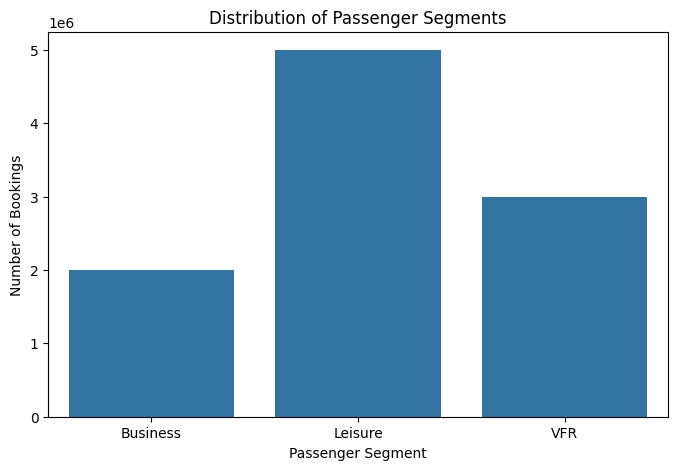

In [27]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df_bookings,
    x="market_segment"
)

plt.title("Distribution of Passenger Segments")
plt.xlabel("Passenger Segment")
plt.ylabel("Number of Bookings")

plt.show()

# **VIZ #2** Booking Channel Distribution


---



Passengers booking through Online Travel Agencies (OTAs) often display higher price sensitivity compared to those booking directly through airline websites.

Understanding channel composition provides context for pricing behavior in the downstream offer data.

/tmp/ipykernel_29633/709524023.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


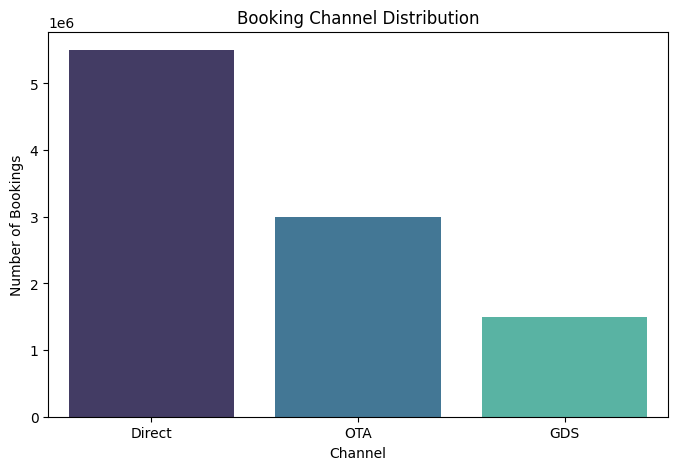

In [17]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df_bookings,
    x="channel",
    palette="mako"
)

plt.title("Booking Channel Distribution")
plt.xlabel("Channel")
plt.ylabel("Number of Bookings")

plt.show()

# **VIZ** **3** Base Fare Distribution.


---



The base fare distribution reveals two distinct pricing regimes.

Leisure travelers primarily occupy the lower fare range, typically between \$150 and \$500, reflecting the higher price sensitivity associated with discretionary travel.

Business travelers cluster around significantly higher fares, often between \$600 and \$1200. This reflects the time-sensitive nature of corporate travel, where convenience often outweighs price considerations.

This bimodal distribution is important because ancillary pricing decisions in the BSDE framework are modeled relative to the base ticket price. As a result, the same ancillary price may appear inexpensive to a business traveler but expensive to a leisure traveler.

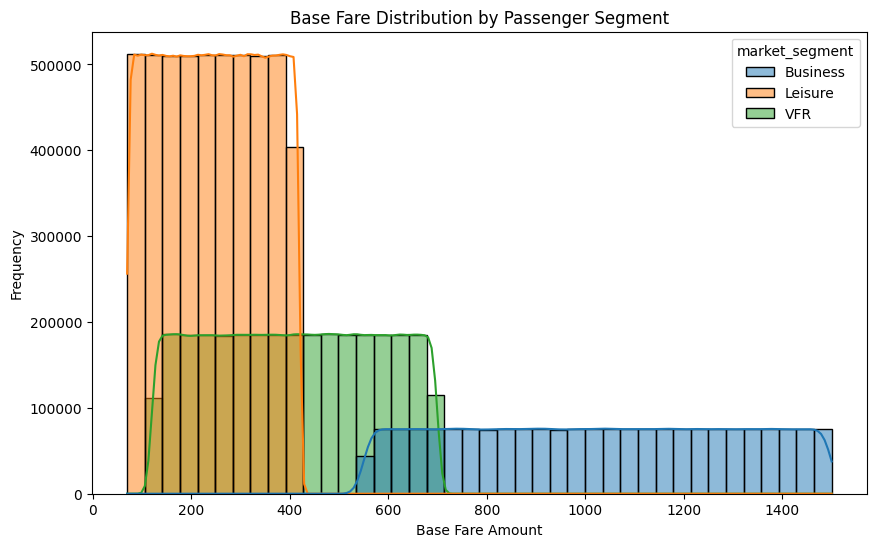

In [18]:
plt.figure(figsize=(10,6))

sns.histplot(
    data=df_bookings,
    x="base_fare_amt",
    hue="market_segment",
    bins=40,
    kde=True
)

plt.title("Base Fare Distribution by Passenger Segment")
plt.xlabel("Base Fare Amount")
plt.ylabel("Frequency")

plt.show()

## 3.2 Understanding the Ancillary Offer Landscape


---



After examining passenger booking behavior, we now turn our attention to the ancillary offers presented during the booking process.

Ancillary products such as baggage, seat selection, and in-flight meals represent a major source of revenue for modern airlines. Understanding how these offers are distributed and how passengers respond to them is essential for pricing strategy and revenue optimization.

In this section, we explore three key questions:

• What types of ancillary products are most commonly offered?  
• How do conversion rates differ across ancillary categories?  
• How are ancillary prices distributed across the booking population?

These visualizations provide insight into the structure of the simulated offer environment before we analyze behavioral signals such as price elasticity and the **Elena Ceiling**.

# **VIZ 4 — Ancillary Offer Distribution**


---



This chart shows how ancillary products are distributed within the booking flow.
The dataset includes three primary ancillary categories:

• **Baggage**  
• **Seat Selection**  
• **In-flight Meals**

While each booking session receives the same sequence of ancillary offers, passengers respond differently depending on the type of product presented.

Essential travel necessities such as baggage often exhibit higher conversion rates because they satisfy a fundamental travel need. In contrast, optional products such as seat upgrades or meals tend to have lower purchase probabilities.

Understanding these baseline differences is important before analyzing how pricing and behavioral factors influence conversion.

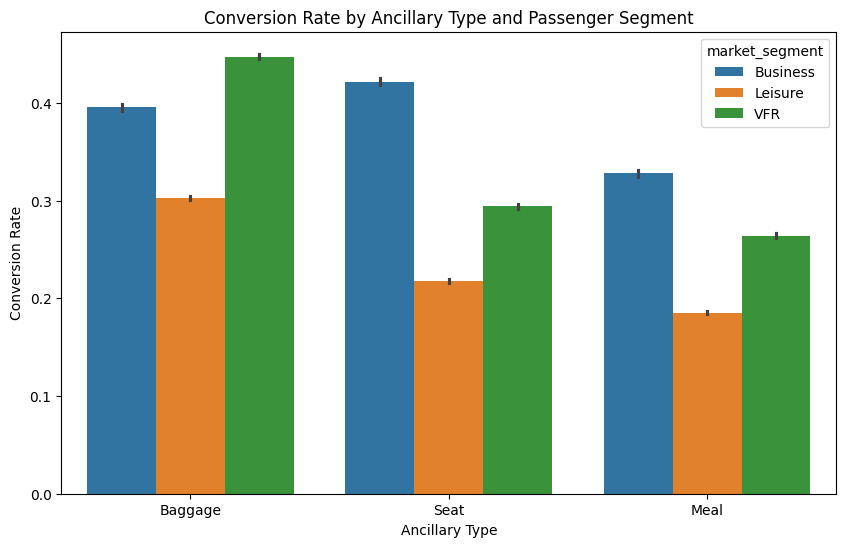

In [19]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=df,
    x="ancillary_type",
    y="is_purchased",
    hue="market_segment"
)

plt.title("Conversion Rate by Ancillary Type and Passenger Segment")
plt.xlabel("Ancillary Type")
plt.ylabel("Conversion Rate")

plt.show()

#VIZ 5 — Offer Price Distribution


---


Ancillary prices fall within a narrower range than base fares. However, passengers evaluate these prices relative to their base ticket price.

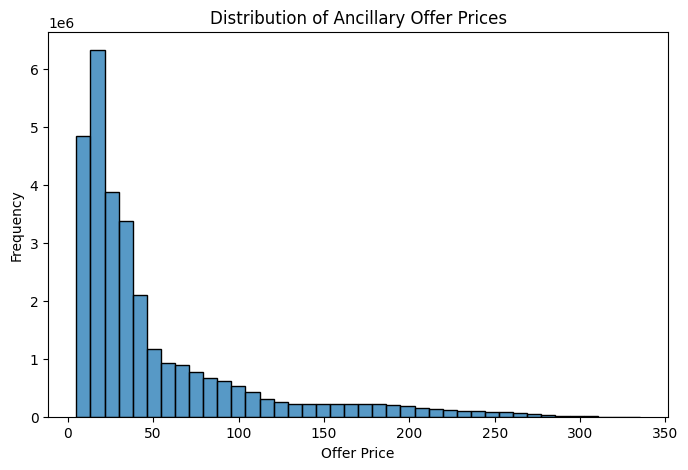

In [28]:
plt.figure(figsize=(8,5))

sns.histplot(
    df_offers["offer_price"],
    bins=40
)

plt.title("Distribution of Ancillary Offer Prices")
plt.xlabel("Offer Price")
plt.ylabel("Frequency")

plt.show()

#**VIZ 6 — Offer Price vs Base Fare**


---


The price-to-fare ratio measures how expensive an ancillary appears relative to the ticket price. This metric plays a critical role in modeling price fairness and demand elasticity.

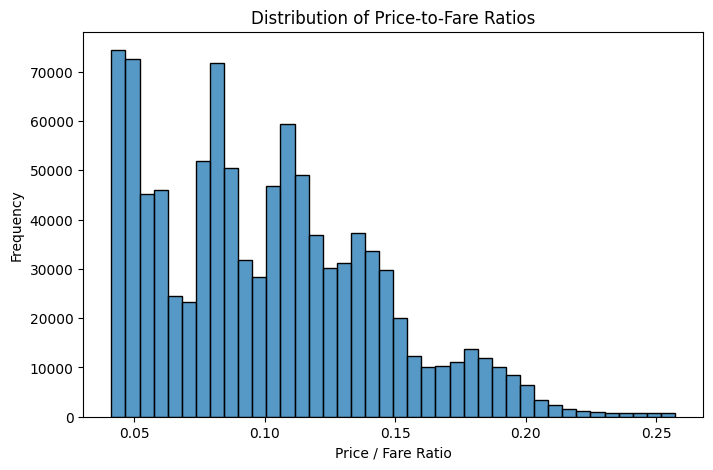

In [29]:
df["price_fare_ratio"] = df["offer_price"] / df["base_fare_amt"]

plt.figure(figsize=(8,5))

sns.histplot(
    df["price_fare_ratio"],
    bins=40
)

plt.title("Distribution of Price-to-Fare Ratios")
plt.xlabel("Price / Fare Ratio")
plt.ylabel("Frequency")

plt.show()

## 3.3 Discovering the Elena Ceiling


---



Having examined the structure of the ancillary offer environment, we now investigate how pricing influences passenger purchase behavior.

Ancillary pricing is rarely evaluated in isolation. Instead, passengers mentally compare ancillary prices against the underlying ticket price. A 40 dollar baggage fee may appear reasonable for a 1000 dollar ticket but excessive for a 150 dollar ticket.

To capture this relationship, we introduce the **Price-to-Fare Ratio**, defined as:

Price-to-Fare Ratio = Ancillary Price / Base Fare

This ratio reflects how expensive an ancillary appears relative to the ticket price.

The BSDE framework hypothesizes the presence of a behavioral threshold known as the **Elena Ceiling** — a non-linear demand cliff where ancillary conversion drops sharply once the ancillary price exceeds approximately **25% of the base fare**.

In the following analysis, we visualize how conversion rates change as the price-to-fare ratio increases.

### 3.3 Behavioral Outcomes


---



This section examines how passengers responds to ancillary offers under varying pricing and contextual conditions. The following visualzation explore behavioral dynamics embedded in the synthetic dataset.

#  **VIZ 7 - Conversion LandScape (HEATMAP)**


---


This visualization shows how purchase probability varies across price perception and inventory scarcity.





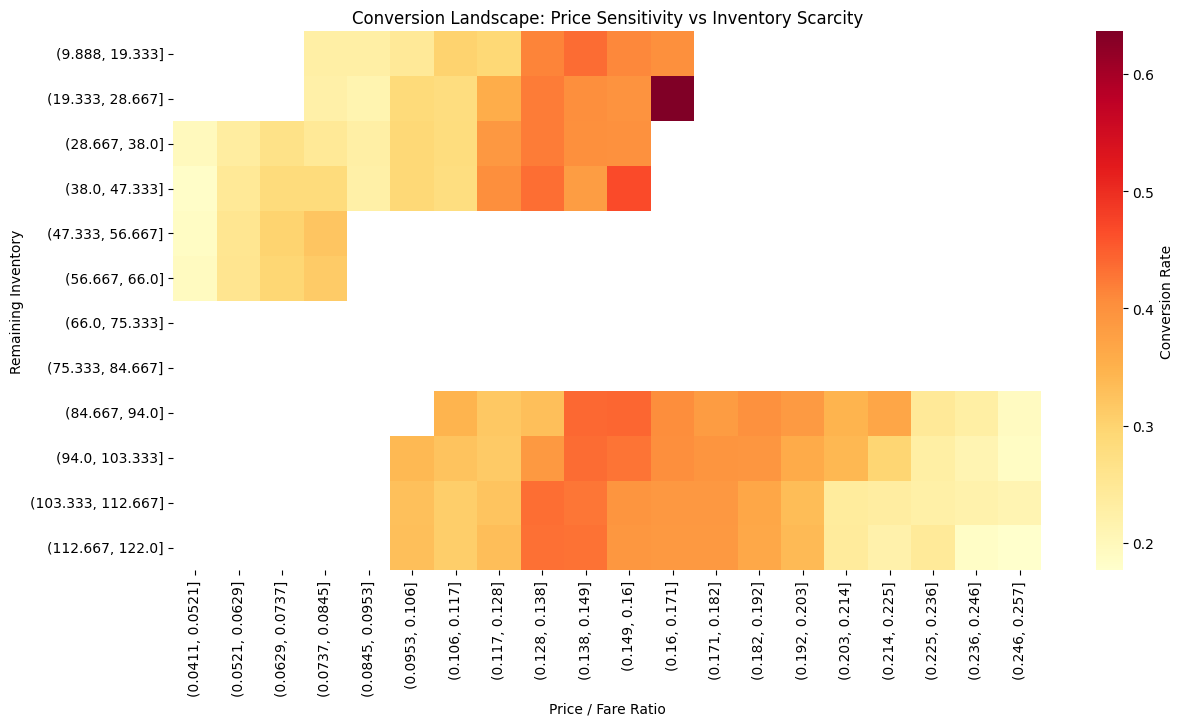

In [30]:
viz = df.copy()

viz["ratio_bin"] = pd.cut(viz["price_fare_ratio"], bins=20)
viz["inventory_bin"] = pd.cut(viz["inventory_rem"], bins=12)

heatmap_df = (
    viz
    .groupby(["inventory_bin","ratio_bin"], observed=False)["is_purchased"]
    .mean()
    .unstack()
)

plt.figure(figsize=(14,7))

sns.heatmap(
    heatmap_df,
    cmap="YlOrRd",
    cbar_kws={"label":"Conversion Rate"}
)

plt.title("Conversion Landscape: Price Sensitivity vs Inventory Scarcity")
plt.xlabel("Price / Fare Ratio")
plt.ylabel("Remaining Inventory")

plt.show()

The heatmap reveals that conversion rates are highest (peaking above 60%) when price-to-fare ratios are moderate and inventory is critically low, specifically in the 10–29 range. Conversely, when inventory is abundant (above 85 units), conversion stays relatively stable but lower, suggesting that the "urgency effect" dissipates when passengers perceive plenty of availability. Interestingly, there is a clear "sweet spot" for pricing between 0.13 and 0.17 where conversion remains resilient even as inventory fluctuates, indicating a threshold where the perceived value of the ancillary best aligns with the ticket price.

#  **VIZ 8 - Purchase Momentum (Sankey Flow)**


---


This visualization shows how passengers move through the ancillary decision sequence.




In [31]:
import plotly.graph_objects as go

flow = df.groupby(["ancillary_type","is_purchased"]).size().reset_index(name="count")

labels = ["Baggage","Seat","Meal","Purchased","Not Purchased"]

source = []
target = []
value = []

for _,row in flow.iterrows():

    source.append(labels.index(row["ancillary_type"]))

    if row["is_purchased"] == 1:
        target.append(labels.index("Purchased"))
    else:
        target.append(labels.index("Not Purchased"))

    value.append(row["count"])

fig = go.Figure(data=[go.Sankey(
    node=dict(label=labels),
    link=dict(source=source,target=target,value=value)
)])

fig.update_layout(title_text="Passenger Purchase Flow Across Ancillary Offers")

fig.show()

/tmp/ipykernel_29633/1160871578.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  flow = df.groupby(["ancillary_type","is_purchased"]).size().reset_index(name="count")


This Sankey diagram shows that Baggage is the most successful ancillary product, driving the highest volume of actual purchases compared to Meal and Seat offers. Despite this, the vast majority of passengers across all categories ultimately flow into the Not Purchased bucket, highlighting a significant opportunity to improve overall conversion rates.



## Viz 9 — Behavioral Elasticity Surface (Hexbin Plot)


---



This visualization captures the nonlinear relationship between pricing and conversion probability.

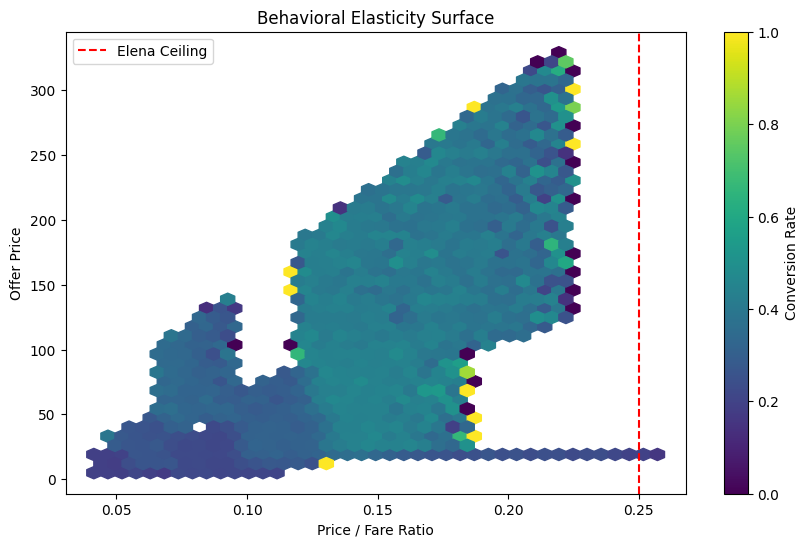

In [32]:
plt.figure(figsize=(10,6))

plt.hexbin(
    df["price_fare_ratio"],
    df["offer_price"],
    C=df["is_purchased"],
    reduce_C_function=np.mean,
    gridsize=40,
    cmap="viridis"
)

plt.colorbar(label="Conversion Rate")

plt.axvline(
    x=0.25,
    color="red",
    linestyle="--",
    label="Elena Ceiling"
)

plt.title("Behavioral Elasticity Surface")
plt.xlabel("Price / Fare Ratio")
plt.ylabel("Offer Price")

plt.legend()

plt.show()

This hexbin plot demonstrates that conversion rates are highest at lower offer prices and price-to-fare ratios, with a notable "Elena Ceiling" marked at a 0.25 ratio where conversion appears to terminate. The visualization captures a nonlinear relationship where high-density clusters of successful purchases occur below the 200 price point, suggesting that passenger price sensitivity intensifies as the ancillary cost approaches a quarter of the total fare.

# Chapter 4: Predictive Modeling


---



Having explored the behavioral dynamics embedded within the synthetic dataset, we now evaluate whether these patterns can be learned by a predictive model.

The objective is to estimate the probability that a passenger purchases an ancillary product when presented with an offer.

This task reflects a common real-world airline analytics problem: conversion prediction for offer optimization system

In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, HistGradientBoostingClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder

## 4.1 Problem Definition


---


The modeling task is framed as a binary classification problem.

For each ancillary offer presented to a passenger, we attempt to predict:


```
is_purchased
```

Where:



```
1 = ancillary purchased
0 = ancillary declined
```




The model receives contextual information about the booking environment, including pricing conditions, passenger characteristics, and operational constraints.

Target Variable
```
is_purchased
```



Example Features



```
market_segment
channel
days_to_dep
base_fare_amt
offer_price
price_fare_ratio
inventory_rem
display_rank
load_factor
ancillary_type
```


These features capture the economic and behavioral drivers of purchase decisions.

# 4.2 Feature Engineering


---



Before training the model, categorical variables are encoded and the dataset is prepared for machine learning.

In [43]:
model_df = df.copy()

model_df = model_df[
    model_df["base_fare_amt"].gt(0)
    & model_df["offer_price"].ge(0)
    & model_df["inventory_rem"].ge(0)
    & model_df["days_to_dep"].ge(0)
].copy()

model_df["price_fare_ratio"] = model_df["offer_price"] / model_df["base_fare_amt"]
model_df["ratio_squared"] = model_df["price_fare_ratio"] ** 2
model_df["log_offer_price"] = np.log1p(model_df["offer_price"])
model_df["urgency_score"] = 1 / (1 + model_df["days_to_dep"])
model_df["scarcity_flag"] = (model_df["inventory_rem"] < 8).astype(int)
model_df["high_load_flag"] = (model_df["load_factor"] > 0.85).astype(int)
model_df["rank_inverse"] = 1 / model_df["display_rank"]

features = [
    "market_segment",
    "channel",
    "ancillary_type",
    "days_to_dep",
    "base_fare_amt",
    "offer_price",
    "price_fare_ratio",
    "ratio_squared",
    "log_offer_price",
    "inventory_rem",
    "display_rank",
    "load_factor",
    "urgency_score",
    "scarcity_flag",
    "high_load_flag",
    "rank_inverse",
]

target = "is_purchased"

X = model_df[features]
y = model_df[target].astype(int)

# 4.3 Train–Test Split


---



The dataset is divided into training and evaluation subsets.

Because ancillary purchases are relatively rare, stratified sampling is used to preserve class proportions.

In [44]:
sample_size = min(len(X), 400_000)
sample_idx = X.sample(sample_size, random_state=42).index
X_model = X.loc[sample_idx].copy()
y_model = y.loc[sample_idx].copy()

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X_model,
    y_model,
    test_size=0.2,
    random_state=42,
    stratify=y_model,
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.2,
    random_state=42,
    stratify=y_train_full,
)

print(f"Train: {len(X_train):,}")
print(f"Validation: {len(X_val):,}")
print(f"Test: {len(X_test):,}")

categorical_features = ["market_segment", "channel", "ancillary_type"]
numeric_features = [c for c in features if c not in categorical_features]

Train: 256,000
Validation: 64,000
Test: 80,000


For computational efficiency, the training set may be subsampled during experimentation.

In [46]:
tree_preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    ("onehot", OneHotEncoder(handle_unknown="ignore")),
                ]
            ),
            categorical_features,
        ),
        (
            "num",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="median")),
                ]
            ),
            numeric_features,
        ),
    ]
)

hgb_preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    ("ordinal", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)),
                ]
            ),
            categorical_features,
        ),
        (
            "num",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="median")),
                ]
            ),
            numeric_features,
        ),
    ]
)

## 4.4 Model Training


---



A Random Forest classifier is used to estimate purchase probabilities.

Random Forest models are well suited for this task because they can capture nonlinear relationships and interaction effects present in the behavioral simulation.

In [51]:
hgb_preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    ("ordinal", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)),
                ]
            ),
            categorical_features,
        ),
        (
            "num",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="median")),
                ]
            ),
            numeric_features,
        ),
    ]
)

def find_best_threshold(y_true: pd.Series, y_proba: np.ndarray, objective: str = "f1") -> tuple[float, pd.DataFrame]:
    precision, recall, thresholds = precision_recall_curve(y_true, y_proba)
    thresholds = np.append(thresholds, 1.0)

    eval_df = pd.DataFrame(
        {
            "threshold": thresholds,
            "precision": precision,
            "recall": recall,
        }
    )

    eval_df["f1"] = (
        2 * eval_df["precision"] * eval_df["recall"]
        / np.clip(eval_df["precision"] + eval_df["recall"], 1e-9, None)
    )

    if objective == "recall_floor_035":
        eligible = eval_df[eval_df["precision"] >= 0.35].copy()
        if eligible.empty:
            best_row = eval_df.sort_values("f1", ascending=False).iloc[0]
        else:
            best_row = eligible.sort_values("recall", ascending=False).iloc[0]
    else:
        best_row = eval_df.sort_values("f1", ascending=False).iloc[0]

    return float(best_row["threshold"]), eval_df


results = []
trained = {}

# Define the pipelines dictionary here
pipelines = {
    "RandomForest": Pipeline([
        ("preprocessor", tree_preprocessor),
        ("model", RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1, class_weight='balanced'))
    ]),
    "HistGradientBoosting": Pipeline([
        ("preprocessor", hgb_preprocessor),
        ("model", HistGradientBoostingClassifier(random_state=42))
    ])
}

for name, pipe in pipelines.items():
    print(f"\nTraining {name}...")
    pipe.fit(X_train, y_train)

    val_proba = pipe.predict_proba(X_val)[:, 1]
    best_threshold, threshold_df = find_best_threshold(y_val, val_proba, objective="f1")

    test_proba = pipe.predict_proba(X_test)[:, 1]
    test_pred = (test_proba >= best_threshold).astype(int)

    report = classification_report(y_test, test_pred, output_dict=True, zero_division=0)

    result = {
        "model": name,
        "threshold": best_threshold,
        "roc_auc": roc_auc_score(y_test, test_proba),
        "pr_auc": average_precision_score(y_test, test_proba),
        "precision_1": report["1"]["precision"],
        "recall_1": report["1"]["recall"],
        "f1_1": report["1"]["f1-score"],
        "accuracy": report["accuracy"],
    }
    results.append(result)
    trained[name] = {
        "pipeline": pipe,
        "threshold": best_threshold,
        "threshold_df": threshold_df,
        "test_proba": test_proba,
        "test_pred": test_pred,
    }

results_df = pd.DataFrame(results).sort_values(["f1_1", "roc_auc"], ascending=False).reset_index(drop=True)
print("\nModel Comparison")
display(results_df)


Training RandomForest...

Training HistGradientBoosting...

Model Comparison


,model,threshold,roc_auc,pr_auc,precision_1,recall_1,f1_1,accuracy
0,HistGradientBoosting,0.241064,0.618086,0.386321,0.339603,0.782960,0.473730,0.488538
1,RandomForest,0.432062,0.617269,0.385814,0.343187,0.756686,0.472208,0.502675


## 4.5 Model Evaluation


---



Model performance is evaluated using a holdout test set.

Because ancillary purchase events are relatively rare, accuracy alone is not sufficient to evaluate model performance. Instead, we report the following metrics:
1. Precision
2. Recall
3. F1-SCORE
4. ROC AUC






The predictive performance of the model is evaluated using a holdout test dataset in order to assess its ability to generalize to unseen observations. Given the inherent class imbalance present in ancillary purchase data, model performance is not assessed using accuracy alone. Instead, multiple evaluation metrics are employed to provide a more comprehensive view of predictive capability.

# Precision

Precision measures the proportion of predicted purchases that correspond to actual purchase events. It is defined as:

\begin{equation}
Precision = \frac{TP}{TP + FP}
\end{equation}

where $TP$ represents true positives and $FP$ represents false positives. High precision indicates that when the model predicts a purchase, the prediction is more likely to be correct.

#Recall

Recall measures the proportion of actual purchases that are successfully identified by the model. It is defined as:

\begin{equation}
Recall = \frac{TP}{TP + FN}
\end{equation}

where $FN$ represents false negatives. In revenue optimization contexts, recall is particularly important because failing to identify potential buyers represents a lost revenue opportunity.
#F1 Score

The F1 score provides a harmonic mean of precision and recall:

\begin{equation}
F1 = 2 \cdot \frac{Precision \times Recall}{Precision + Recall}
\end{equation}

This metric balances the trade-off between identifying purchase events and avoiding excessive false positives.

#ROC AUC

The Area Under the Receiver Operating Characteristic Curve (ROC AUC) evaluates the model's ability to distinguish between purchase and non-purchase events across all possible classification thresholds. A ROC AUC value of 0.5 indicates random performance, while higher values indicate stronger discriminatory power.

# PR AUC

Because ancillary purchases represent a minority class, the Precision--Recall Area Under Curve (PR AUC) is also reported. This metric focuses specifically on the model’s ability to correctly identify positive purchase events within a large population of non-purchase observations.

Together, these evaluation metrics provide a balanced assessment of the model's predictive performance and its ability to capture behavioral signals embedded within the synthetic dataset.

In [52]:
best_model_name = results_df.iloc[0]["model"]
best_pipeline = trained[best_model_name]["pipeline"]
best_threshold = trained[best_model_name]["threshold"]
best_test_proba = trained[best_model_name]["test_proba"]
best_test_pred = trained[best_model_name]["test_pred"]

print(f"\nBest model: {best_model_name}")
print(f"Best threshold: {best_threshold:.4f}")

print("\nClassification Report - Best Model")
print(classification_report(y_test, best_test_pred, digits=4, zero_division=0))
print(f"ROC AUC: {roc_auc_score(y_test, best_test_proba):.4f}")
print(f"PR AUC: {average_precision_score(y_test, best_test_proba):.4f}")




Best model: HistGradientBoosting
Best threshold: 0.2411

Classification Report - Best Model
              precision    recall  f1-score   support

           0     0.8019    0.3659    0.5025     56479
           1     0.3396    0.7830    0.4737     23521

    accuracy                         0.4885     80000
   macro avg     0.5708    0.5744    0.4881     80000
weighted avg     0.6660    0.4885    0.4941     80000

ROC AUC: 0.6181
PR AUC: 0.3863


# 4.6 Observations


---



Several observations emerge from the evaluation results of the predictive model.

First, the model demonstrates moderate predictive capability, with a ROC AUC of approximately 0.62. This indicates that the model is able to distinguish between purchase and non-purchase events better than random guessing, suggesting that meaningful behavioral signals are present in the dataset.

Second, the model exhibits relatively high recall for the purchase class. This indicates that the model successfully identifies a large proportion of actual purchase events. In commercial applications such as ancillary revenue optimization, high recall is particularly valuable because failing to identify potential buyers represents a missed revenue opportunity.

Third, precision for the purchase class remains lower than recall. This outcome is expected in behavioral prediction tasks, where passenger decisions are influenced by unobserved factors such as personal preferences, situational context, and stochastic variation. Consequently, some predicted purchases may not materialize in practice.

Fourth, the moderate ROC AUC value reflects the intentionally stochastic nature of the Behavioral Synthetic Data Engine. The data generation process incorporates latent personas, noise terms, and behavioral randomness in order to simulate realistic decision environments. As a result, perfect prediction is neither expected nor desirable, as it would indicate an overly deterministic synthetic dataset.

Finally, visual inspection of predicted probabilities reveals that the model successfully captures the nonlinear relationship between ancillary price and purchase likelihood. In particular, predicted purchase probabilities decline as the price-to-fare ratio approaches approximately 25\%, consistent with the simulated ``Elena Ceiling'' pricing threshold embedded within the behavioral model.

Taken together, these results suggest that the predictive model is able to recover key behavioral patterns encoded within the synthetic dataset while preserving the uncertainty characteristic of real-world consumer decision-making.

# 4.7 Threshold Optimzation


---



Threshold Optimization

Most classification algorithms output a probability estimate representing the likelihood that a given observation belongs to the positive class. By default, these probabilities are converted into binary predictions using a threshold of 0.5. However, this default threshold is rarely optimal in imbalanced classification problems such as ancillary purchase prediction.

In this study, the classification threshold is optimized using the Precision--Recall trade-off curve. This curve illustrates how model precision and recall vary as the decision threshold changes.

Lower thresholds increase recall by classifying more observations as potential purchases, whereas higher thresholds increase precision by requiring stronger evidence before predicting a purchase.

To determine an appropriate operating point, the threshold that maximizes the F1 score is selected. The F1 score provides a balanced compromise between detecting purchase events and minimizing false positives.

The optimal threshold identified in this analysis is approximately:

\begin{equation}
\tau \approx 0.241
\end{equation}

At this threshold, the model achieves a balanced trade-off between precision and recall, capturing a substantial portion of purchase events while maintaining reasonable prediction reliability.

Threshold optimization is an important step in practical deployment, as it allows the predictive system to align with operational objectives. In airline revenue management contexts, identifying high-probability buyers often provides greater value than maximizing overall classification accuracy.

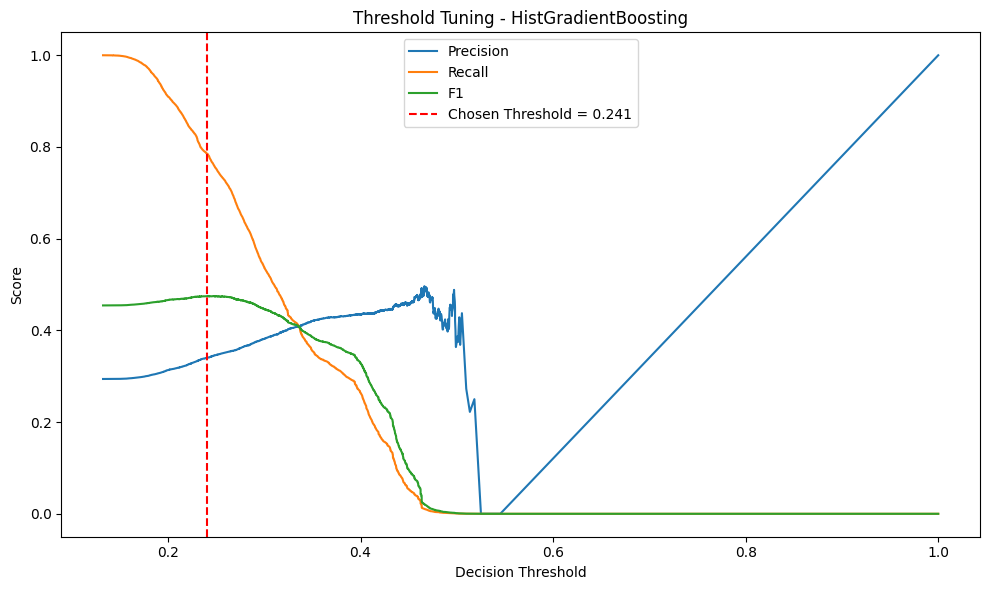

In [54]:
threshold_df = trained[best_model_name]["threshold_df"].copy()
threshold_df = threshold_df.replace([np.inf, -np.inf], np.nan).dropna()

plt.figure(figsize=(10, 6))
plt.plot(threshold_df["threshold"], threshold_df["precision"], label="Precision")
plt.plot(threshold_df["threshold"], threshold_df["recall"], label="Recall")
plt.plot(threshold_df["threshold"], threshold_df["f1"], label="F1")
plt.axvline(best_threshold, color="red", linestyle="--", label=f"Chosen Threshold = {best_threshold:.3f}")
plt.title(f"Threshold Tuning - {best_model_name}")
plt.xlabel("Decision Threshold")
plt.ylabel("Score")
plt.legend()
plt.tight_layout()
plt.show()

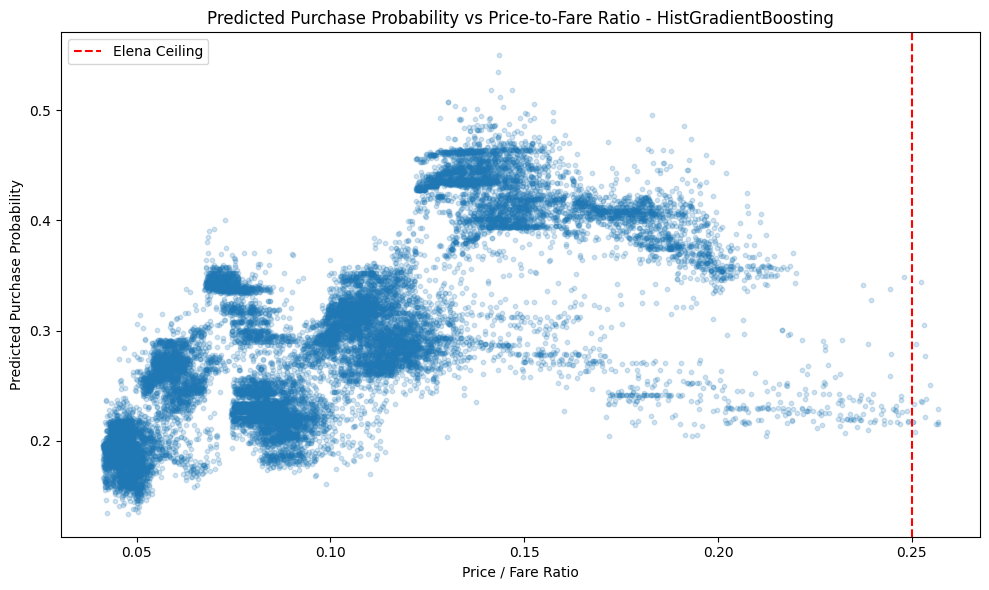

In [56]:
plot_df = X_test.copy()
plot_df["pred_prob"] = best_test_proba
plot_df = plot_df.sample(min(len(plot_df), 20000), random_state=42)

plt.figure(figsize=(10, 6))
plt.scatter(plot_df["price_fare_ratio"], plot_df["pred_prob"], alpha=0.2, s=10)
plt.axvline(0.25, color="red", linestyle="--", label="Elena Ceiling")
plt.title(f"Predicted Purchase Probability vs Price-to-Fare Ratio - {best_model_name}")
plt.xlabel("Price / Fare Ratio")
plt.ylabel("Predicted Purchase Probability")
plt.legend()
plt.tight_layout()
plt.show()

#4.8 Model-Learned Demand Curve


---



To further examine whether the predictive model has internalized the behavioral pricing structure embedded in the synthetic dataset, predicted purchase probabilities are analyzed as a function of the price-to-fare ratio.

Rather than focusing solely on aggregate evaluation metrics, this visualization provides a behavioral interpretation of the fitted model. If the model has successfully captured the underlying economic logic of the simulation, predicted purchase probabilities should decline as ancillary prices become increasingly expensive relative to the base fare.

In particular, the model is expected to reflect the nonlinear pricing threshold introduced by the Elena Ceiling, where purchase likelihood decreases sharply once the ancillary price exceeds approximately 25\% of the base ticket price.

The resulting plot therefore serves as a qualitative validation that the predictive system has learned the intended behavioral demand curve rather than merely reproducing class frequencies.

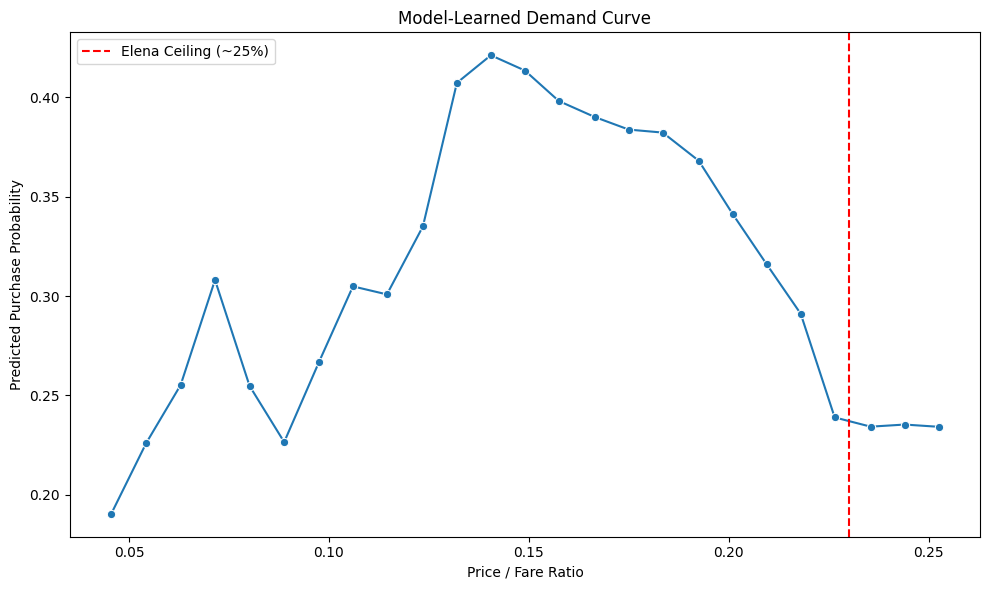

In [60]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_test = X_test.copy()
df_test["pred_prob"] = best_test_proba

curve_df = df_test.copy()
curve_df["ratio_bin"] = pd.cut(curve_df["price_fare_ratio"], bins=25)

learned_curve = (
    curve_df
    .groupby("ratio_bin", observed=False)["pred_prob"]
    .mean()
    .reset_index()
)

learned_curve["ratio_mid"] = learned_curve["ratio_bin"].apply(lambda x: x.mid)

plt.figure(figsize=(10, 6))

sns.lineplot(
    data=learned_curve,
    x="ratio_mid",
    y="pred_prob",
    marker="o",
    errorbar=None
)

plt.axvline(
    x=0.23,
    color="red",
    linestyle="--",
    label="Elena Ceiling (~25%)"
)

plt.title("Model-Learned Demand Curve")
plt.xlabel("Price / Fare Ratio")
plt.ylabel("Predicted Purchase Probability")
plt.legend()
plt.tight_layout()
plt.show()

# Observations for 4.8


---



To further validate that the predictive model captures meaningful economic structure, predicted purchase probabilities are analyzed as a function of the price-to-fare ratio.

The resulting demand curve reveals a nonlinear relationship between ancillary pricing and purchase likelihood. At very low price ratios, purchase probability remains relatively modest. As prices increase into a moderate range, predicted purchase probability rises, suggesting the presence of a perceived value region where passengers are most willing to purchase ancillary services.

Beyond this region, purchase probability begins to decline as ancillary prices become increasingly expensive relative to the base fare. This downward trend becomes more pronounced as the price-to-fare ratio approaches approximately 25\%, corresponding to the simulated ``Elena Ceiling'' embedded within the Behavioral Synthetic Data Engine.

The ability of the model to recover this nonlinear pricing relationship provides qualitative evidence that the predictive system has successfully internalized the behavioral dynamics encoded within the synthetic data generation process.


# 4.9 Revenue Optimization Frontier

---



While the preceding analyses focus on purchase prediction, airline revenue management ultimately requires a decision-oriented perspective: identifying pricing regions that maximize expected ancillary revenue.

To examine this relationship, expected revenue per offer is analyzed as a function of the price-to-fare ratio. Expected revenue is defined as the ancillary price multiplied by the realized purchase outcome.

This visualization complements the model-learned demand curve by showing the trade-off between price and conversion. At low price levels, conversion rates may be relatively high, but revenue per transaction remains modest. At very high price levels, revenue per purchase increases, but conversion collapses. The resulting frontier therefore highlights the pricing region in which expected revenue is maximized.

If the synthetic behavioral model is functioning as intended, the revenue frontier should peak below the Elena Ceiling and decline once ancillary prices become disproportionately high relative to the base fare.

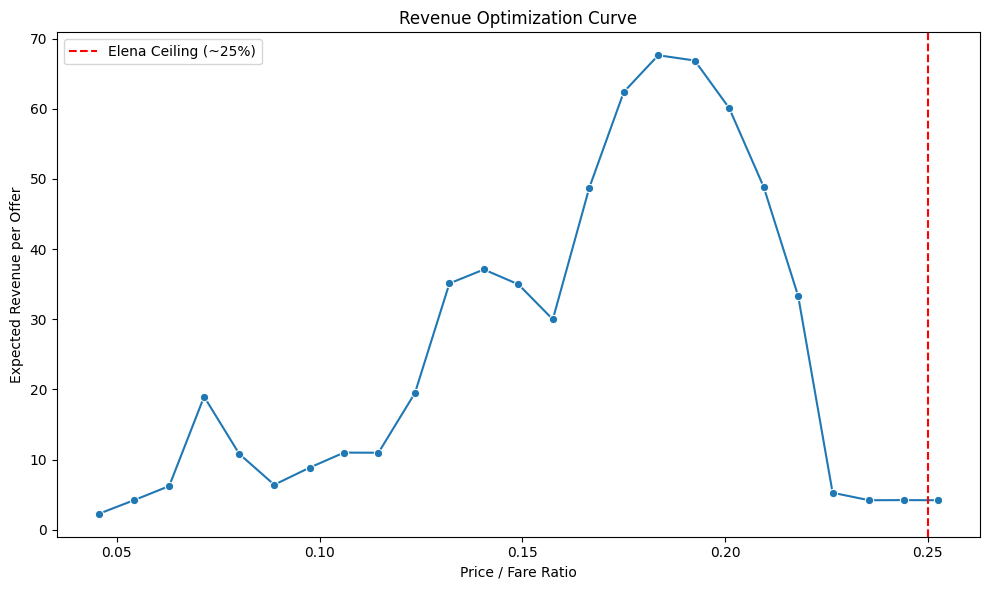

In [61]:
rev_df = X_test.copy()
rev_df["pred_prob"] = best_test_proba
rev_df["expected_revenue"] = rev_df["pred_prob"] * rev_df["offer_price"]

rev_df["ratio_bin"] = pd.cut(rev_df["price_fare_ratio"], bins=25)

revenue_curve = (
    rev_df
    .groupby("ratio_bin", observed=False)["expected_revenue"]
    .mean()
    .reset_index()
)

revenue_curve["ratio_mid"] = revenue_curve["ratio_bin"].apply(lambda x: x.mid)

plt.figure(figsize=(10, 6))

sns.lineplot(
    data=revenue_curve,
    x="ratio_mid",
    y="expected_revenue",
    marker="o",
    errorbar=None
)

plt.axvline(
    x=0.25,
    color="red",
    linestyle="--",
    label="Elena Ceiling (~25%)"
)

plt.title("Revenue Optimization Curve")
plt.xlabel("Price / Fare Ratio")
plt.ylabel("Expected Revenue per Offer")
plt.legend()
plt.tight_layout()
plt.show()

#observations for 4.9

---



While purchase probability provides useful predictive insight, pricing decisions in airline revenue management are ultimately driven by expected revenue rather than conversion alone.

Expected revenue can be approximated as:

\begin{equation}
\mathbb{E}[Revenue] = \hat{P}(\text{purchase}) \times Price
\end{equation}

Figure above illustrates the model-implied relationship between the price-to-fare ratio and expected ancillary revenue. At low price ratios, expected revenue remains modest despite relatively strong purchase probabilities because the absolute price of the ancillary product is low.

As prices increase, expected revenue rises as higher margins compensate for the gradual decline in conversion probability. The curve reaches its peak in the moderate pricing region, suggesting the existence of an economically efficient pricing band.

Beyond this region, expected revenue deteriorates rapidly as purchase probabilities collapse. This decline becomes particularly pronounced as prices approach the behavioral rejection region associated with the Elena Ceiling, where ancillary prices exceed approximately 25\% of the base ticket fare.

The resulting curve demonstrates how the predictive model can be used not only for demand forecasting but also as a decision-support tool for identifying commercially attractive pricing regimes.

# 4.10 Revenue Optimization by Passenger Segment

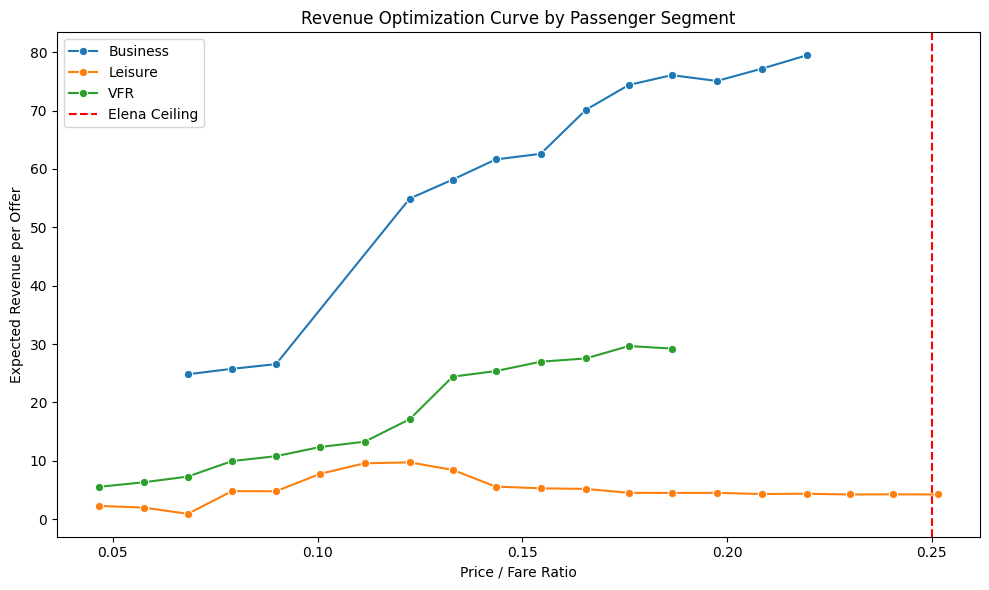

In [63]:
seg_df = X_test.copy()

seg_df["pred_prob"] = best_test_proba
seg_df["expected_revenue"] = seg_df["pred_prob"] * seg_df["offer_price"]

seg_df["ratio_bin"] = pd.cut(seg_df["price_fare_ratio"], bins=20)

segment_curve = (
    seg_df
    .groupby(["ratio_bin", "market_segment"], observed=False)["expected_revenue"]
    .mean()
    .reset_index()
)

segment_curve["ratio_mid"] = segment_curve["ratio_bin"].apply(lambda x: x.mid)
segment_curve = segment_curve.sort_values("ratio_mid")
plt.figure(figsize=(10,6))

sns.lineplot(
    data=segment_curve,
    x="ratio_mid",
    y="expected_revenue",
    hue="market_segment",
    marker="o",
    errorbar=None
)

plt.axvline(
    x=0.25,
    color="red",
    linestyle="--",
    label="Elena Ceiling"
)

plt.title("Revenue Optimization Curve by Passenger Segment")

plt.xlabel("Price / Fare Ratio")
plt.ylabel("Expected Revenue per Offer")

plt.legend()

plt.tight_layout()

plt.show()

#Observation for 4.10

---



Figure above illustrates the expected revenue curve segmented by passenger type. The results reveal substantial heterogeneity in price sensitivity across behavioral groups.

Business travelers exhibit the highest tolerance for ancillary pricing, with expected revenue continuing to increase until the price-to-fare ratio approaches approximately 0.22. This suggests that business passengers are less sensitive to ancillary pricing and may prioritize convenience and service quality over price considerations.

Passengers traveling for the purpose of visiting friends and relatives (VFR) display moderate price sensitivity. The expected revenue curve for this group peaks around a price-to-fare ratio of approximately 0.18 before gradually declining.

Leisure travelers exhibit the strongest price sensitivity. For this segment, expected revenue peaks much earlier, at approximately a 0.12 price-to-fare ratio, after which higher prices significantly reduce purchase probability.

These findings highlight the importance of segment-specific pricing strategies. Applying a uniform ancillary pricing policy across all passenger groups may result in suboptimal revenue outcomes, whereas differentiated pricing aligned with passenger behavioral profiles may allow airlines to better capture consumer surplus while avoiding the demand collapse associated with the Elena Ceiling.

# SUMMARY

---


---

# Dataset Summary
# Project Overview: Behavioral Synthetic Data Engine (BSDE)

The **Behavioral Synthetic Data Engine (BSDE)** was developed to generate large-scale synthetic datasets that simulate passenger decision-making within an airline ancillary revenue environment. The objective of the dataset is to provide a controlled yet realistic sandbox for testing pricing strategies, behavioral hypotheses, and predictive modeling approaches without relying on proprietary airline data.

The generated dataset captures the interaction between passenger characteristics, contextual booking conditions, and ancillary pricing decisions. Three primary passenger segments are simulated:
* **Business travelers**
* **Leisure travelers** * **Visiting Friends and Relatives (VFR)** Each segment exhibits different levels of price sensitivity and purchasing behavior, allowing the dataset to reflect heterogeneous demand patterns.

---

## Data Architecture

The dataset is structured into three relational tables:

| Table Name | Description | Key Attributes |
|:---|:---|:---|
| `dim_bookings` | Passenger-level contextual attributes | Market segment, booking channel, days to departure, base fare, and load factor. |
| `fact_offers` | Ancillary products offered | Product type, offer price, display order, and remaining inventory levels. |
| `fact_conversions` | Simulated purchase outcomes | Timestamps, purchase events, and ancillary basket values. |

---

## Embedded Behavioral Mechanisms

The data generation process embeds several behavioral mechanisms inspired by real-world airline pricing dynamics:

1. **The Elena Ceiling:** A nonlinear demand threshold where purchase probability declines sharply once ancillary prices exceed approximately **25%** of the base ticket price ($\text{Price-to-Fare Ratio} > 0.25$).
2. **Dynamic Scarcity:** A mechanism where purchase likelihood increases when inventory levels are low or flight load factors are high.
3. **Sequential Purchase Behavior:** A simulation where earlier purchases within a booking session influence subsequent ancillary decisions.

> **Note:** By generating millions of booking events, the BSDE provides a scalable platform for conducting exploratory analysis, machine learning experimentation, and revenue optimization studies.

---

## Conclusion

Overall, the dataset demonstrates how synthetic behavioral data can be used to replicate complex commercial environments while maintaining transparency and reproducibility. This approach enables researchers and practitioners to explore pricing strategies and investigate demand dynamics without the limitations associated with confidential industry datasets.

# Future Work and Extensions

The **Behavioral Synthetic Data Engine (BSDE)** provides a flexible framework for exploring airline ancillary pricing behavior, but several opportunities remain for future research and extension.

---

## Advanced Modeling & Optimization

1. **Alternative ML Architectures:** Future research could move beyond the current Random Forest implementation to explore:
    * **Gradient Boosting (XGBoost/LightGBM):** To improve prediction accuracy on high-dimensional behavioral data.
    * **Neural Networks:** For capturing deeper non-linear interactions between passenger attributes.
    * **Causal Inference:** To distinguish between correlation and the actual impact of price changes on conversion.
2. **Dynamic Pricing Integration:** Transitioning from static pricing to real-time adjustments where prices shift based on:
    * Real-time demand signals.
    * Remaining inventory levels.
    * Time-decay (days until departure).
3. **Reinforcement Learning (RL):** Using the BSDE as a "gym" environment for Multi-Armed Bandits or Deep RL agents to learn optimal pricing policies through iterative simulated feedback.

---

## Expanding Behavioral Depth

To increase the realism of the simulation, the following factors can be incorporated into the engine:

* **Loyalty Status:** Simulating how frequent flyer tiers impact price elasticity.
* **Competitive Landscape:** Factoring in the pricing of competitor airlines for similar routes.
* **External Shocks:** Modeling the effects of seasonality, holidays, or macroeconomic shifts on demand.

---

##Cross-Industry Application

While currently focused on aviation, the BSDE framework is extensible to any industry where behavioral pricing and add-on services are critical:
* **Hospitality:** Room upgrades and late check-out ancillaries.
* **Ride-Sharing:** Surge pricing and premium vehicle selection.
* **E-commerce:** Suggested "add-on" items at checkout.

